In [1]:
import sklearn
from sklearn.preprocessing import StandardScaler
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")

coffee_data['target'] = coffee_data['caffeine_class'].map(lambda x: 0 if x == 'Absent' else 1)

scaler = StandardScaler()
X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent', 'target']))
print(X_scaled_std.shape)
X_scaled_std

(526, 17)


array([[-0.93472065,  0.75249166,  0.73780235, ...,  1.58901671,
         0.93143833,  0.84250201],
       [ 0.16475749, -0.44480758,  0.06972861, ..., -1.93397837,
         1.39926106,  1.37477113],
       [-0.73838527,  1.24792583,  1.80672034, ...,  0.56017744,
        -0.54824819, -1.06246113],
       ...,
       [ 0.79303071,  0.50477458,  0.27015073, ..., -1.63260121,
         0.8236814 , -0.3901212 ],
       [ 0.79303071,  0.50477458,  0.27015073, ..., -1.63260121,
         0.8236814 , -0.3901212 ],
       [-1.20959019,  1.99107708,  1.33906872, ...,  1.27724723,
         0.01681859, -1.06246113]])

In [8]:
y = coffee_data['target']
X = X_scaled_std.copy()

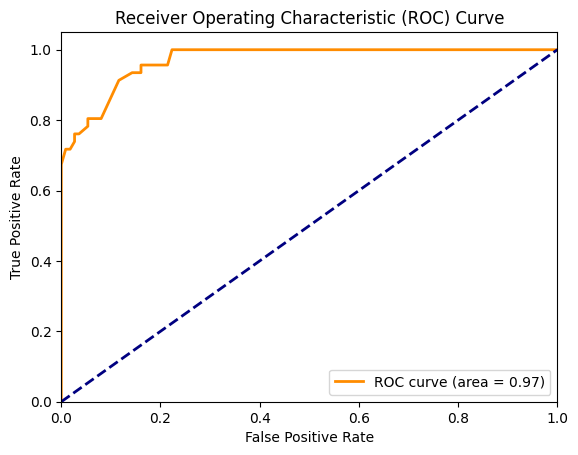

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Logistic Regression model
#model = LogisticRegression()
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get predicted probabilities for the positive class (class 1)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Calculate the False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate the Area Under the ROC Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
